In [3]:
import pandas as pd
import numpy as n
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("/content/Logistic_bank-full.csv")
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [6]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')

In [7]:
df.isna().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

# Exploratory Data Analysis

In [8]:
data = ["age","balance","day","duration","campaign","pdays","previous"]

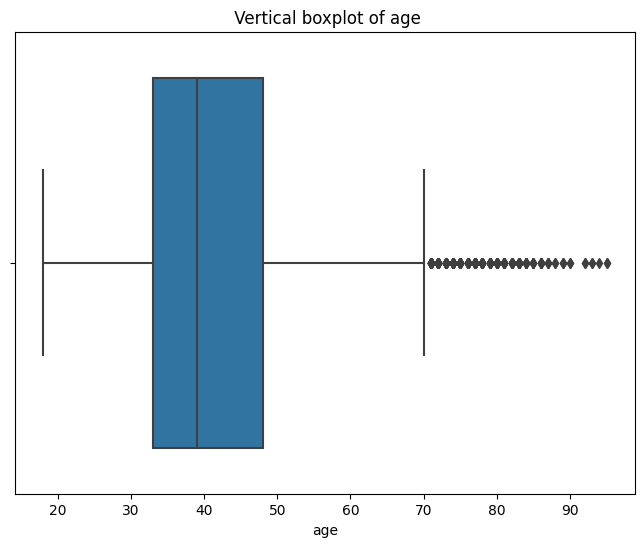

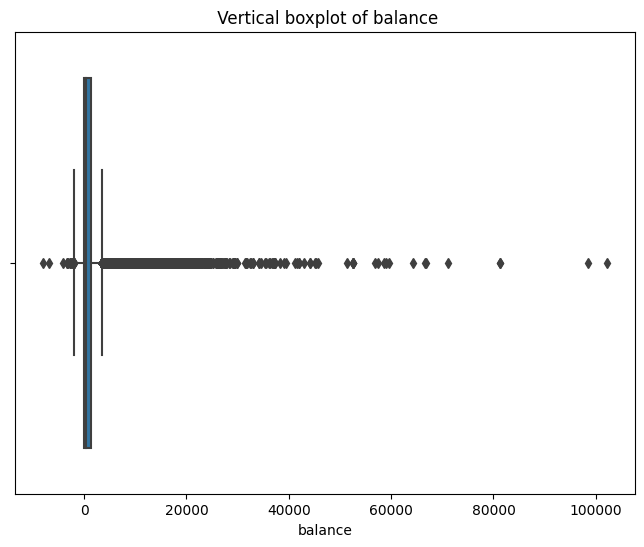

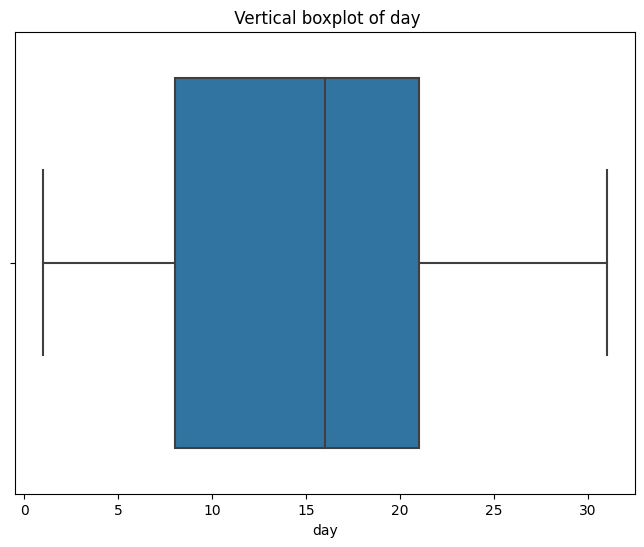

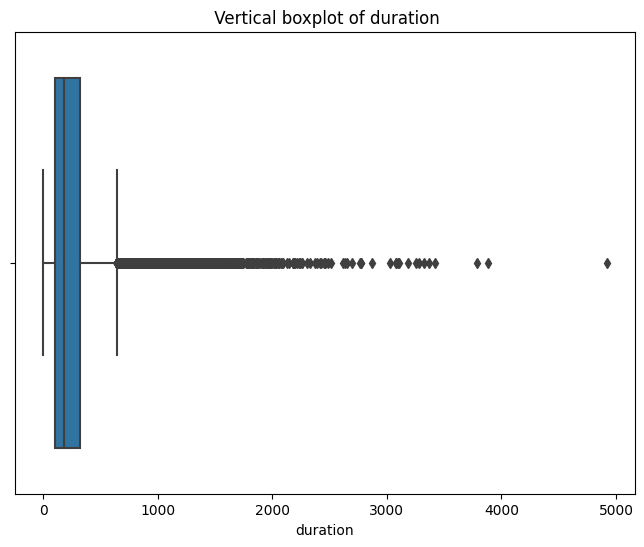

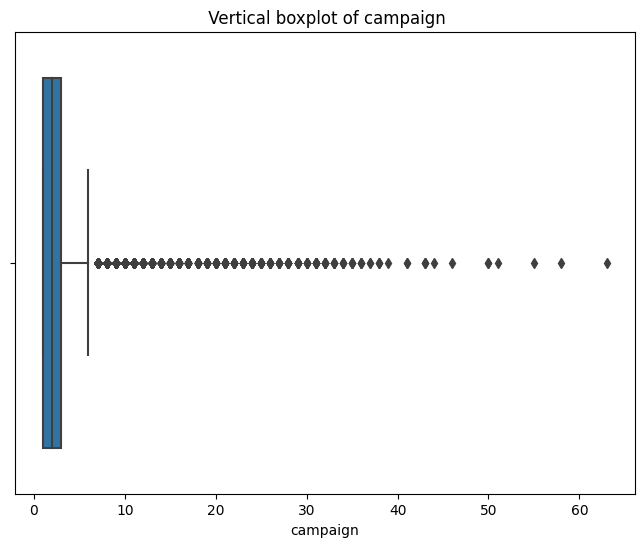

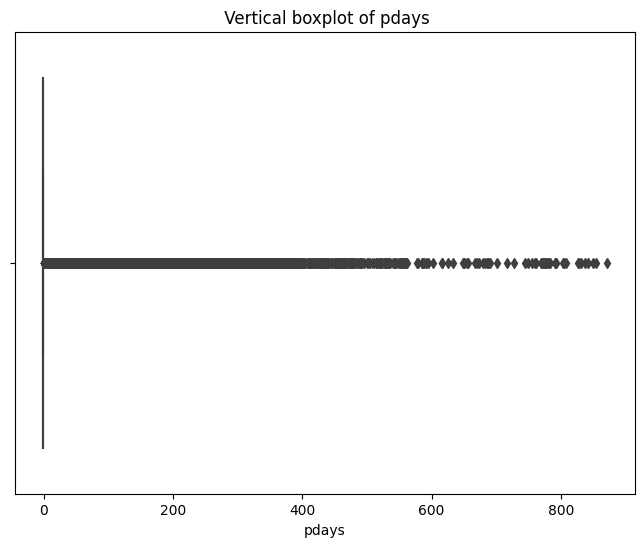

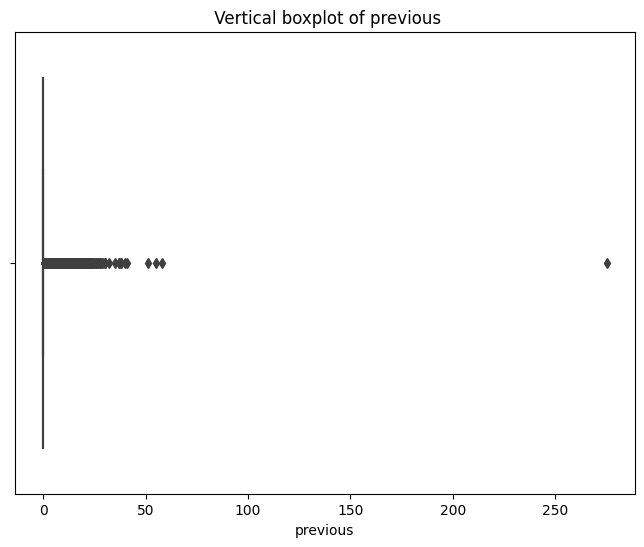

In [9]:
for i in data:
    plt.figure(figsize=(8,6))
    sns.boxplot(x=df[i])
    plt.title(f" Vertical boxplot of {i}")
    plt.show

In [39]:
#removing outliers
continuous_columns = ["age", "balance","duration","campaign","pdays","previous" ]

data_without_outliers = df.copy()
for df.cloumns in continuous_columns:
    Q1 = data_without_outliers[i].quantile(0.25)
    Q3 = data_without_outliers[i].quantile(0.75)
    IQR = Q3 - Q1
    lower_whisker_Length = Q1 - 1.5 * IQR
    upper_whisker_Length = Q3 + 1.5 * IQR
    data_without_outliers = data_without_outliers[(data_without_outliers[i] >= lower_whisker_Length) & (data_without_outliers[i]<= upper_whisker_Length)]
# Print the cleaned data without outliers
print(data_without_outliers)
df = data_without_outliers
print(df)


KeyError: ignored

<Axes: >

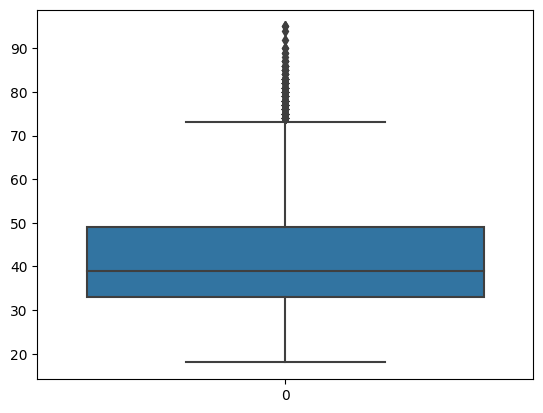

In [11]:
sns.boxplot(df["age"])

In [12]:
"""data division and standard {ew izing"""
df_cont = df.iloc[:,[0,5,9,11,12,13,14]]
df_cont
df_cont.info()


<class 'pandas.core.frame.DataFrame'>
Int64Index: 36954 entries, 0 to 45209
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   age       36954 non-null  int64
 1   balance   36954 non-null  int64
 2   day       36954 non-null  int64
 3   duration  36954 non-null  int64
 4   campaign  36954 non-null  int64
 5   pdays     36954 non-null  int64
 6   previous  36954 non-null  int64
dtypes: int64(7)
memory usage: 3.3 MB


In [13]:
from sklearn.preprocessing import StandardScaler
SS = StandardScaler()
X1 = SS.fit_transform(df_cont)
X1= pd.DataFrame(X1)
X1.columns=list(df_cont)
X1


,age,balance,day,duration,campaign,pdays,previous
0,1.636380,0.271165,-1.331204,0.012484,-0.577903,0.0,0.0
1,0.294108,-0.424340,-1.331204,-0.406959,-0.577903,0.0,0.0
2,-0.760534,-0.433223,-1.331204,-0.692942,-0.577903,0.0,0.0
3,0.581738,0.061592,-1.331204,-0.631933,-0.577903,0.0,0.0
4,-0.760534,-0.433552,-1.331204,-0.227742,-0.577903,0.0,0.0
...,...,...,...,...,...,...,...
36949,-1.719300,-0.396704,0.102070,0.031549,-0.577903,0.0,0.0
36950,-1.527547,-0.267736,0.102070,0.489123,-0.277218,0.0,0.0
36951,0.965244,-0.162456,0.102070,2.742673,0.023466,0.0,0.0
36952,2.882776,0.134959,0.102070,0.756041,-0.277218,0.0,0.0


<ipython-input-14-7452d86f8334>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['age'])


<Axes: xlabel='age', ylabel='Density'>

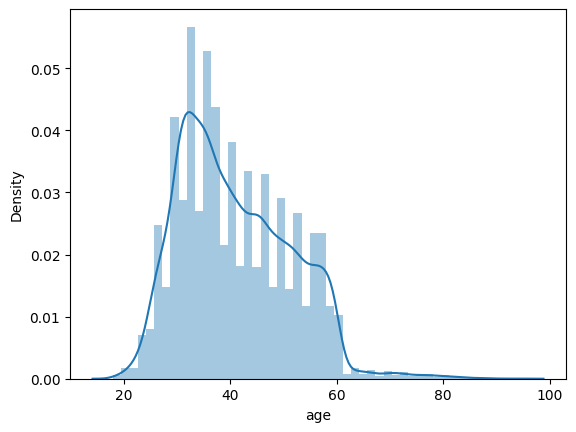

In [14]:
sns.distplot(df['age'])

<ipython-input-15-1774855127ec>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['balance'])


<Axes: xlabel='balance', ylabel='Density'>

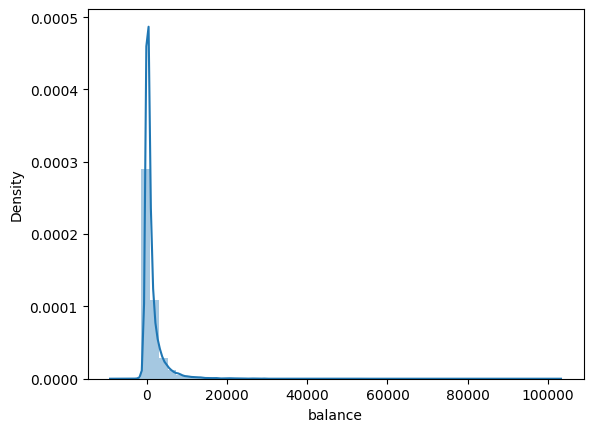

In [15]:
sns.distplot(df['balance'])

In [16]:
df_cat = df.iloc[:,[1,2,3,4,6,7,8,10,15]]
df_cat


,job,marital,education,default,housing,loan,contact,month,poutcome
0,management,married,tertiary,no,yes,no,unknown,may,unknown
1,technician,single,secondary,no,yes,no,unknown,may,unknown
2,entrepreneur,married,secondary,no,yes,yes,unknown,may,unknown
3,blue-collar,married,unknown,no,yes,no,unknown,may,unknown
4,unknown,single,unknown,no,no,no,unknown,may,unknown
...,...,...,...,...,...,...,...,...,...
45203,student,single,tertiary,no,no,no,cellular,nov,unknown
45205,technician,single,secondary,no,no,yes,cellular,nov,unknown
45206,technician,married,tertiary,no,no,no,cellular,nov,unknown
45207,retired,divorced,primary,no,no,no,cellular,nov,unknown


# performing LAabel encoding


In [17]:
from sklearn.preprocessing import LabelEncoder
LE = LabelEncoder()
for i in range(0,9):
    df_cat.iloc[:,i] = LE.fit_transform(df_cat.iloc[:,i])
df_cat.head()


<ipython-input-17-11a182a41f47>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cat.iloc[:,i] = LE.fit_transform(df_cat.iloc[:,i])
<ipython-input-17-11a182a41f47>:4: DeprecationWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  df_cat.iloc[:,i] = LE.fit_transform(df_cat.iloc[:,i])
<ipython-input-17-11a182a41f47>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs

,job,marital,education,default,housing,loan,contact,month,poutcome
0,4,1,2,0,1,0,2,8,0
1,9,2,1,0,1,0,2,8,0
2,2,1,1,0,1,1,2,8,0
3,1,1,3,0,1,0,2,8,0
4,11,2,3,0,0,0,2,8,0


In [18]:
X = pd.concat([df_cont,df_cat],axis = 1)
X

,age,balance,day,duration,campaign,pdays,previous,job,marital,education,default,housing,loan,contact,month,poutcome
0,58,2143,5,261,1,-1,0,4,1,2,0,1,0,2,8,0
1,44,29,5,151,1,-1,0,9,2,1,0,1,0,2,8,0
2,33,2,5,76,1,-1,0,2,1,1,0,1,1,2,8,0
3,47,1506,5,92,1,-1,0,1,1,3,0,1,0,2,8,0
4,33,1,5,198,1,-1,0,11,2,3,0,0,0,2,8,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45203,23,113,17,266,1,-1,0,8,2,2,0,0,0,0,9,0
45205,25,505,17,386,2,-1,0,9,2,1,0,0,1,0,9,0
45206,51,825,17,977,3,-1,0,9,1,2,0,0,0,0,9,0
45207,71,1729,17,456,2,-1,0,5,0,0,0,0,0,0,9,0


In [19]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 36954 entries, 0 to 45209
Data columns (total 16 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        36954 non-null  int64
 1   balance    36954 non-null  int64
 2   day        36954 non-null  int64
 3   duration   36954 non-null  int64
 4   campaign   36954 non-null  int64
 5   pdays      36954 non-null  int64
 6   previous   36954 non-null  int64
 7   job        36954 non-null  int64
 8   marital    36954 non-null  int64
 9   education  36954 non-null  int64
 10  default    36954 non-null  int64
 11  housing    36954 non-null  int64
 12  loan       36954 non-null  int64
 13  contact    36954 non-null  int64
 14  month      36954 non-null  int64
 15  poutcome   36954 non-null  int64
dtypes: int64(16)
memory usage: 5.8 MB


In [20]:
Y = df.iloc[:,16:17]
Y


,y
0,no
1,no
2,no
3,no
4,no
...,...
45203,yes
45205,yes
45206,yes
45207,yes


In [21]:
from sklearn.preprocessing import LabelEncoder
LE = LabelEncoder()
Y.iloc[:,0] = LE.fit_transform(Y.iloc[:,0])
Y


<ipython-input-21-17a63d25fab0>:3: DeprecationWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  Y.iloc[:,0] = LE.fit_transform(Y.iloc[:,0])


,y
0,0
1,0
2,0
3,0
4,0
...,...
45203,1
45205,1
45206,1
45207,1


In [22]:

""" #  data partition and data validation#
from sklearn.model_selection import train_test_split
#by default it will take 75% of data as training data if we donot mention in the code#
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,train_size = 0.75,random_state = 15)
X_train.shape
X_test.shape"""


' #  data partition and data validation#\nfrom sklearn.model_selection import train_test_split\n#by default it will take 75% of data as training data if we donot mention in the code#\nX_train,X_test,Y_train,Y_test = train_test_split(X,Y,train_size = 0.75,random_state = 15)\nX_train.shape\nX_test.shape'

# performing modelbuidling  

In [23]:
"""fitting the model   here we fitted all the X and Y variables data i.e., complete data"""
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression()
logreg.fit(X,Y)
Y_pred = logreg.predict(X)
Y_pred



/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


array([0, 0, 0, ..., 0, 0, 0])

In [24]:
logreg.predict_proba(X)[:,1]
df["Y_probabilities"] = logreg.predict_proba(X)[:,1]


In [25]:
#Function to change the cut off
def f1(X):
    if X<0.4:
        return 0
    elif X>=0.4:
        return 1


In [26]:
df["Y_prob"] = df["Y_probabilities"].apply(f1)
df


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,Y_probabilities,Y_prob
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no,0.034874,0
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no,0.031602,0
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no,0.035702,0
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no,0.024922,0
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no,0.064043,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45203,23,student,single,tertiary,no,113,no,no,cellular,17,nov,266,1,-1,0,unknown,yes,0.171888,0
45205,25,technician,single,secondary,no,505,no,yes,cellular,17,nov,386,2,-1,0,unknown,yes,0.169411,0
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes,0.399995,0
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes,0.084780,0


In [27]:
Y_p = df["Y_prob"]
Y_p


0        0
1        0
2        0
3        0
4        0
        ..
45203    0
45205    0
45206    0
45207    0
45209    0
Name: Y_prob, Length: 36954, dtype: int64

In [28]:
from sklearn.metrics import confusion_matrix,accuracy_score
cm = confusion_matrix(Y,Y_p)
cm


array([[32875,   695],
       [ 2520,   864]])

In [29]:
ac = accuracy_score(Y,Y_p)
ac

0.91299994587866

In [30]:
#Validation set approach
from sklearn.model_selection import train_test_split
import numpy as np

training_accuracy = []
test_accuracy = []

for i in range(1,101):
    X_train,X_test,Y_train,Y_test=train_test_split(X,Y,train_size=0.75,random_state=i)
    logreg.fit(X_train,Y_train)
    Y_pred_train =logreg.predict(X_train)
    Y_pred_test =logreg.predict(X_test)
    training_accuracy.append(accuracy_score(Y_train,Y_pred_train))
    test_accuracy.append(accuracy_score(Y_test,Y_pred_test))
print("Average Training accuracy ",np.mean(training_accuracy).round(3))
print("Average Test accuracy ",np.mean(test_accuracy).round(3))


/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel

Average Training accuracy  0.914
Average Test accuracy  0.913


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [31]:
from sklearn.metrics import recall_score,precision_score,f1_score
print("Sensitivity score:",recall_score(Y,Y_pred).round(3))
print("Precision score:",precision_score(Y,Y_pred).round(3))
print("F1 score:",f1_score(Y,Y_pred).round(3))

TN =cm[0,0]
FP =cm[1,0]

TNR = TN/(TN+FP)

print("Specificity:",TNR.round(3))


Sensitivity score: 0.187
Precision score: 0.59
F1 score: 0.284
Specificity: 0.929


In [32]:
#K-fold
from sklearn.model_selection import KFold
kf = KFold(n_splits=5)


In [33]:
for train_index,test_index in kf.split(range(11,143)):
    print(train_index)
    print(test_index)



[ 27  28  29  30  31  32  33  34  35  36  37  38  39  40  41  42  43  44
  45  46  47  48  49  50  51  52  53  54  55  56  57  58  59  60  61  62
  63  64  65  66  67  68  69  70  71  72  73  74  75  76  77  78  79  80
  81  82  83  84  85  86  87  88  89  90  91  92  93  94  95  96  97  98
  99 100 101 102 103 104 105 106 107 108 109 110 111 112 113 114 115 116
 117 118 119 120 121 122 123 124 125 126 127 128 129 130 131]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26]
[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  54  55  56  57  58  59  60  61  62
  63  64  65  66  67  68  69  70  71  72  73  74  75  76  77  78  79  80
  81  82  83  84  85  86  87  88  89  90  91  92  93  94  95  96  97  98
  99 100 101 102 103 104 105 106 107 108 109 110 111 112 113 114 115 116
 117 118 119 120 121 122 123 124 125 126 127 128 129 130 131]
[27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 4

In [34]:
training_accuracy = []
test_accuracy = []

for train_index,test_index in kf.split(X):
    X_train,X_test = X.iloc[train_index],X.iloc[test_index]
    Y_train,Y_test= Y.iloc[train_index],Y.iloc[test_index]
    logreg = LogisticRegression()
    logreg.fit(X_train,Y_train)
    Y_pred_train =logreg.predict(X_train)
    Y_pred_test =logreg.predict(X_test)
    training_accuracy.append(accuracy_score(Y_train,Y_pred_train))
    test_accuracy.append(accuracy_score(Y_test,Y_pred_test))

/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel

In [35]:
print("K-Fold Training accuracy ",np.mean(training_accuracy).round(3))
print("K-Fold Test accuracy ",np.mean(test_accuracy).round(3))


K-Fold Training accuracy  0.914
K-Fold Test accuracy  0.912


In [36]:
# ROC Curve plotting and finding AUC value
from sklearn.metrics import roc_auc_score,roc_curve
fpr,tpr,dummy = roc_curve(Y,Y_p)


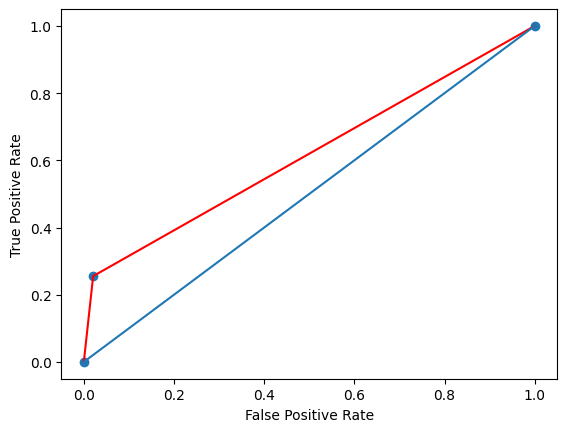

In [37]:
import matplotlib.pyplot as plt
plt.scatter(x=fpr,y=tpr)
plt.plot(fpr,tpr,color='red')
plt.plot([0,1],[0,1])
plt.ylabel("True Positive Rate")
plt.xlabel("False Positive Rate")
plt.show()



In [38]:
auc = roc_auc_score(Y,Y_p)
print("Area under curve:",(auc*100).round(3))

Area under curve: 61.731
